<a href="https://colab.research.google.com/github/anamacao/FAPESP-PIBIC-scrapping/blob/main/senado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# %%
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import sqlite3
import plotly.express as px
import plotly.io as pio

# Ativando explicitamente o renderizador do Colab
pio.renderers.default = "colab"
print("Renderizador Plotly definido para Colab.")

Renderizador Plotly definido para Colab.


In [20]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.0 MB/s eta 0:00:00


In [2]:
# %%
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

BASE_URL = "https://www12.senado.leg.br/noticias/ultimas"
DATABASE_NAME = "internet_governance_news.db"

print("Scraper Senado Notícias pronto!")


Scraper Senado Notícias pronto!


In [3]:
# %%
def create_database():
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS articles (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            title TEXT,
            date TEXT,
            author TEXT,
            url TEXT UNIQUE,
            source TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("✅ Banco e tabela prontos")

create_database()


✅ Banco e tabela prontos


In [4]:
# %%
def insert_article(title, date, author, url, source):
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    try:
        cursor.execute("""
            INSERT INTO articles (title, date, author, url, source)
            VALUES (?, ?, ?, ?, ?)
        """, (title, date, author, url, source))
        conn.commit()
        return True
    except sqlite3.IntegrityError:
        return False
    finally:
        conn.close()


In [5]:
# %%
def montar_url(pagina):
    if pagina == 1:
        return BASE_URL
    return f"{BASE_URL}/{pagina}"


In [6]:
# %%
noticias = []
TOTAL_PAGES = 2719
inserted = 0

for pagina in range(TOTAL_PAGES, 0, -1):
    url = montar_url(pagina)
    print(f"Coletando pagina {pagina}: {url}")

    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f"  Erro {r.status_code} ao acessar pagina {pagina}")
            continue
    except requests.exceptions.RequestException as e:
        print(f"  Erro de conexao na pagina {pagina}: {e}")
        continue

    soup = BeautifulSoup(r.text, "html.parser")
    lista = soup.find("ol", class_="lista-resultados")
    if not lista:
        continue

    itens = lista.find_all("li", recursive=False)
    print(f"  {len(itens)} noticias encontradas")

    for item in itens:
        titulo_tag = item.find("span", class_="eta")
        link_tag = item.find("a", href=True)
        data_tag = item.select_one("div.text-muted.normalis")

        if not titulo_tag or not link_tag:
            continue

        link = link_tag["href"]
        if link.startswith("/"):
            link = "https://www12.senado.leg.br" + link

        titulo = titulo_tag.get_text(strip=True)
        data = data_tag.get_text(strip=True) if data_tag else "NA"

        if insert_article(
            title=titulo,
            date=data,
            author="Agencia Senado",
            url=link,
            source="Agencia Senado"
        ):
            inserted += 1

        noticias.append({
            "titulo": titulo,
            "data": data,
            "link": link,
            "pagina": pagina
        })

    time.sleep(1)

print(f"\n Total de novas noticias inseridas no banco: {inserted}")

A saída de streaming foi truncada nas últimas 5000 linhas.
Coletando pagina 2499: https://www12.senado.leg.br/noticias/ultimas/2499
  20 noticias encontradas
Coletando pagina 2498: https://www12.senado.leg.br/noticias/ultimas/2498
  20 noticias encontradas
Coletando pagina 2497: https://www12.senado.leg.br/noticias/ultimas/2497
  20 noticias encontradas
Coletando pagina 2496: https://www12.senado.leg.br/noticias/ultimas/2496
  20 noticias encontradas
Coletando pagina 2495: https://www12.senado.leg.br/noticias/ultimas/2495
  20 noticias encontradas
Coletando pagina 2494: https://www12.senado.leg.br/noticias/ultimas/2494
  20 noticias encontradas
Coletando pagina 2493: https://www12.senado.leg.br/noticias/ultimas/2493
  20 noticias encontradas
Coletando pagina 2492: https://www12.senado.leg.br/noticias/ultimas/2492
  20 noticias encontradas
Coletando pagina 2491: https://www12.senado.leg.br/noticias/ultimas/2491
  20 noticias encontradas
Coletando pagina 2490: https://www12.senado.leg.br

In [7]:
def load_articles():
    conn = sqlite3.connect(DATABASE_NAME)
    df = pd.read_sql("""
        SELECT * FROM articles
        ORDER BY date DESC
    """, conn)
    conn.close()
    return df

df_db = load_articles()
print(f"📦 Total no banco: {len(df_db)} registros")
display(df_db.head(20))


📦 Total no banco: 48634 registros


,id,title,date,author,url,source
0,37197,P20 é oportunidade de buscar recursos para age...,31/10/2024 18h26,Agencia Senado,https://www12.senado.leg.br/noticias/audios/20...,Agencia Senado
1,37198,"Na CRA, debatedores pedem menos tributos na ca...",31/10/2024 18h18,Agencia Senado,https://www12.senado.leg.br/noticias/materias/...,Agencia Senado
2,37199,Senado recebe projeto que cria o Comitê Gestor...,31/10/2024 18h15,Agencia Senado,https://www12.senado.leg.br/noticias/materias/...,Agencia Senado
3,37161,Debatedores destacam bons exemplos na abordage...,31/10/2024 17h59,Agencia Senado,https://www12.senado.leg.br/noticias/materias/...,Agencia Senado
4,37200,Debate aponta importância de atendimento para ...,31/10/2024 17h59,Agencia Senado,https://www12.senado.leg.br/noticias/materias/...,Agencia Senado
5,37162,Servidores defendem plano de carreira único pa...,31/10/2024 17h41,Agencia Senado,https://www12.senado.leg.br/noticias/materias/...,Agencia Senado
6,37163,Combate ao lúpus: debatedores cobram mais reum...,31/10/2024 17h23,Agencia Senado,https://www12.senado.leg.br/noticias/videos/20...,Agencia Senado
7,37164,Debate cobra melhorias no atendimento a pacien...,31/10/2024 17h18,Agencia Senado,https://www12.senado.leg.br/noticias/audios/20...,Agencia Senado
8,37165,Criação de agência contra ataques cibernéticos...,31/10/2024 17h10,Agencia Senado,https://www12.senado.leg.br/noticias/materias/...,Agencia Senado
9,37166,CCJ avaliará uso de recursos de multas para cu...,31/10/2024 17h00,Agencia Senado,https://www12.senado.leg.br/noticias/audios/20...,Agencia Senado


In [17]:
def plot_charts(df):
    if df.empty:
        print("❌ Sem dados para gráficos")
        return

    top15 = df.head(15).copy()
    top15['rank'] = range(1, len(top15) + 1)

    fig1 = px.bar(
        top15,
        x='rank',
        y='title',
        orientation='h',
        title='Top 15 Notícias – Internet Governance'
    )
    fig1.update_layout(height=600)
    display(fig1)

    source_count = df["source"].value_counts().reset_index()
    source_count.columns = ["source", "count"]

    fig2 = px.pie(
        source_count,
        names="source",
        values="count",
        title="Distribuição por Fonte"
    )
    display(fig2)


    text = ' '.join(df['title'].astype(str)).lower()
    # Corrigindo o regex para extrair palavras com mais de 4 letras
    words = re.findall(r'\b\w{4,}\b', text)

    wc = (
        pd.Series(words)
        .value_counts()
        .head(20)
        .reset_index()
    )
    wc.columns = ['palavra', 'freq']

    fig3 = px.treemap(
        wc,
        path=['palavra'],
        values='freq',
        title='Nuvem de Palavras – Títulos'
    )
    display(fig3)

In [15]:
# %%
plot_charts(df_db)

In [21]:
# Tentativa de renderização estática agora que kaleido está instalado
import plotly.io as pio

try:
    # Recriando o top15 para garantir o contexto
    top15 = df_db.head(15).copy()
    top15['rank'] = range(1, len(top15) + 1)

    print("Gerando gráficos estáticos...")

    # Gráfico de Barras
    fig_bar = px.bar(top15, x='rank', y='title', orientation='h', title='Top 15 Notícias (Estático)')
    fig_bar.show(renderer="png")

    # Distribuição por Fonte
    source_count = df_db["source"].value_counts().reset_index()
    source_count.columns = ["source", "count"]
    fig_pie = px.pie(source_count, names="source", values="count", title="Distribuição por Fonte (Estático)")
    fig_pie.show(renderer="png")

    print("\nOs gráficos acima foram gerados no modo estático para garantir a visualização.")
except Exception as e:
    print(f"Erro ao gerar imagem estática: {e}")

Gerando gráficos estáticos...
Erro ao gerar imagem estática: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Renderizando visualizações aprimoradas...


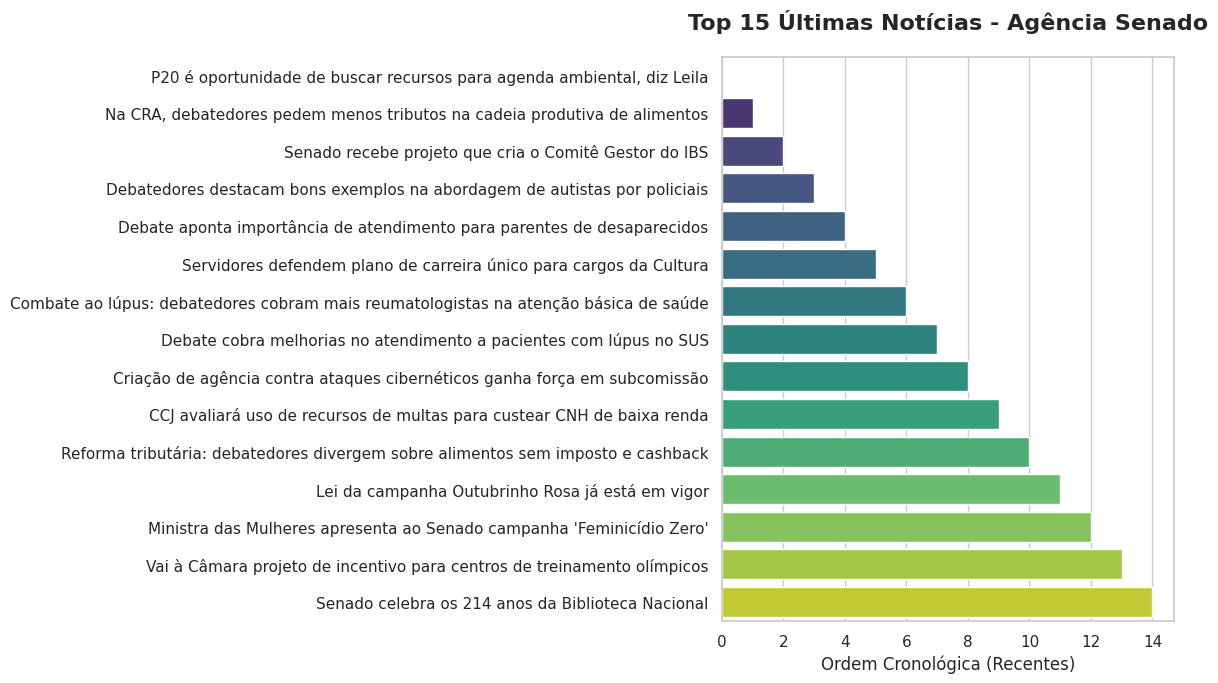

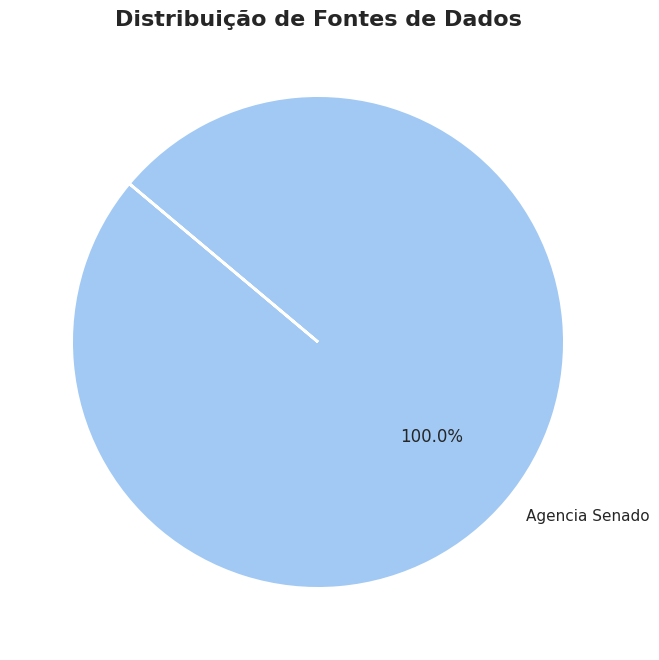

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando um estilo visual mais moderno
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("Renderizando visualizações aprimoradas...")

try:
    # 1. Gráfico de Barras Horizontal (Top 15)
    plt.figure(figsize=(12, 7))
    top15_plt = df_db.head(15).copy()

    # Criando o gráfico com Seaborn
    ax = sns.barplot(
        data=top15_plt,
        y='title',
        x=top15_plt.index,
        palette="viridis",
        hue='title',
        legend=False
    )

    plt.title('Top 15 Últimas Notícias - Agência Senado', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Ordem Cronológica (Recentes)', fontsize=12)
    plt.ylabel('', fontsize=12)

    # Ajustando rótulos para não cortar
    plt.tight_layout()
    plt.show()

    # 2. Distribuição por Fonte
    plt.figure(figsize=(8, 8))
    source_data = df_db['source'].value_counts()

    colors = sns.color_palette('pastel')[0:5]
    plt.pie(
        source_data,
        labels=source_data.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    plt.title('Distribuição de Fontes de Dados', fontsize=16, fontweight='bold')
    plt.show()

except Exception as e:
    print(f"Erro ao renderizar gráficos aprimorados: {e}")

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preparação dos dados temporais
df_temporal = df_db.copy()

# Ajustando o formato da string de data para substituir 'h' por ':'
df_temporal['date_clean'] = df_temporal['date'].str.replace('h', ':', regex=False)

# Conversão para datetime
df_temporal['date_dt'] = pd.to_datetime(df_temporal['date_clean'], format='%d/%m/%Y %H:%M', errors='coerce')

# Extrair apenas a data (dia)
df_temporal['just_date'] = df_temporal['date_dt'].dt.date

# 1. Frequência por Data
daily_freq = df_temporal['just_date'].dropna().value_counts().sort_index()

# 2. Frequência por Autor
author_freq = df_temporal['author'].value_counts()

print("Estatísticas temporais calculadas com sucesso.")
print(f"Registros com data válida: {len(df_temporal['date_dt'].dropna())} de {len(df_temporal)}")
display(daily_freq.tail(10))

Estatísticas temporais calculadas com sucesso.
Registros com data válida: 48634 de 48634


,count
just_date,
2026-04-17,23
2026-04-22,15
2026-04-23,14
2026-04-24,13
2026-04-27,19
2026-04-28,58
2026-04-29,36
2026-04-30,18
2026-05-04,25


In [27]:
# Visualização da Evolução Temporal
plt.figure(figsize=(15, 6))
if not daily_freq.empty:
    sns.lineplot(x=daily_freq.index, y=daily_freq.values, color='#2ecc71', linewidth=2)
    plt.title('Evolução Temporal de Publicações - Agência Senado', fontsize=16, fontweight='bold')
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Quantidade de Notícias', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Não há dados temporais válidos para exibir.")

# Visualização de Autores
if len(author_freq) > 1:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=author_freq.values[:10], y=author_freq.index[:10], palette='magma', hue=author_freq.index[:10], legend=False)
    plt.title('Top Autores por Volume de Notícias', fontsize=16, fontweight='bold')
    plt.show()
else:
    print(f"Nota: Todos os registros pertencem ao mesmo autor: {author_freq.index[0]}")

Não há dados temporais válidos para exibir.
Nota: Todos os registros pertencem ao mesmo autor: Agencia Senado


<Figure size 1500x600 with 0 Axes>

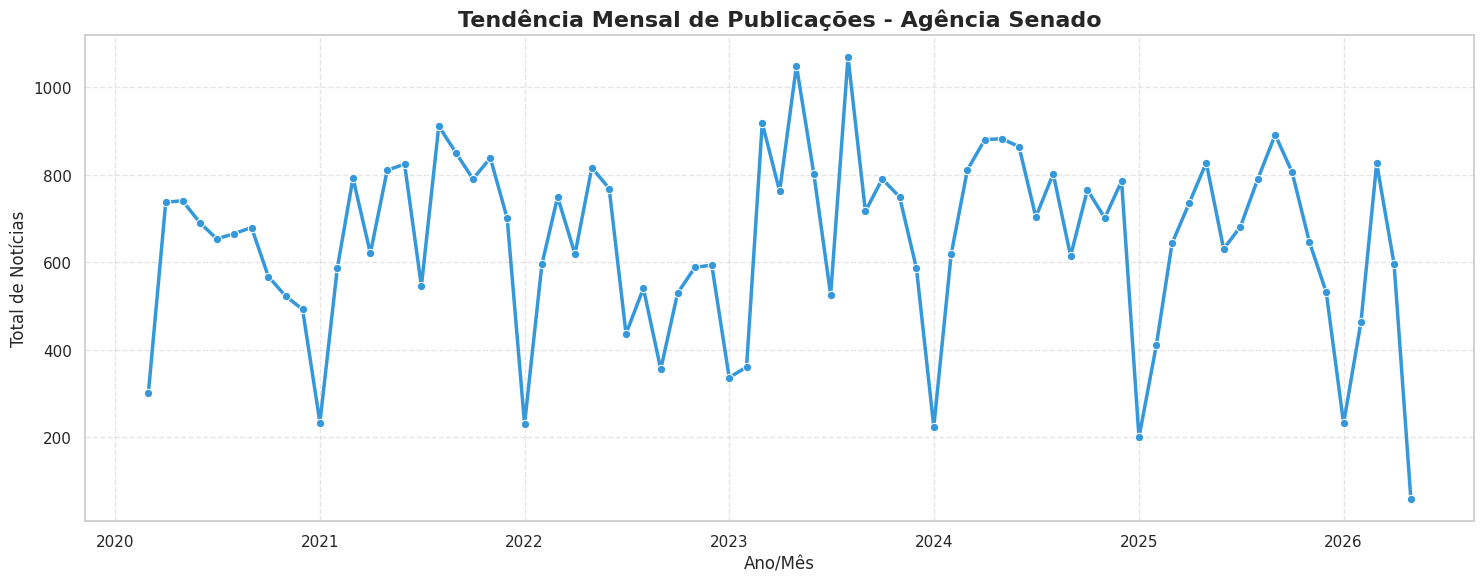

Resumo dos últimos meses:


,count
month_year,
2025-06-01,630
2025-07-01,681
2025-08-01,790
2025-09-01,891
2025-10-01,806
2025-11-01,646
2025-12-01,531
2026-01-01,231
2026-02-01,463


In [29]:
# Agregação por Mês para Tendência de Longo Prazo
df_temporal['month_year'] = df_temporal['date_dt'].dt.to_period('M')
monthly_freq = df_temporal['month_year'].dropna().value_counts().sort_index()

# Converter o índice de Period para Datetime para plotagem correta no Seaborn
monthly_freq.index = monthly_freq.index.to_timestamp()

plt.figure(figsize=(15, 6))
sns.lineplot(x=monthly_freq.index, y=monthly_freq.values, marker='o', color='#3498db', linewidth=2.5)

plt.title('Tendência Mensal de Publicações - Agência Senado', fontsize=16, fontweight='bold')
plt.xlabel('Ano/Mês', fontsize=12)
plt.ylabel('Total de Notícias', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Exibir os últimos meses para conferência
print("Resumo dos últimos meses:")
display(monthly_freq.tail(12))

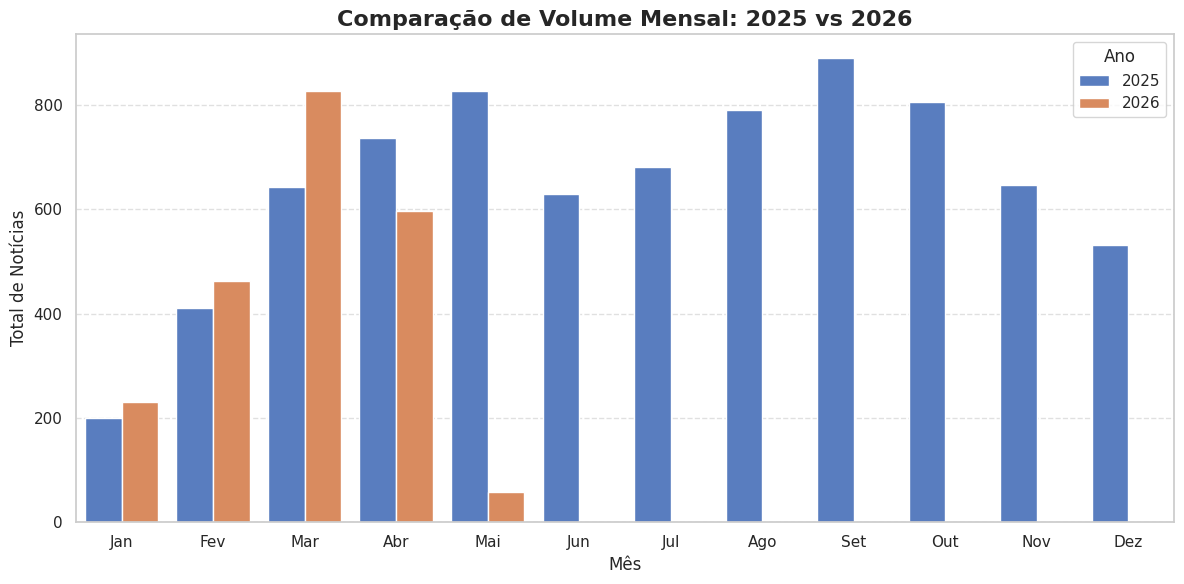

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrando dados para os anos de 2025 e 2026
df_comp = df_temporal[df_temporal['date_dt'].dt.year.isin([2025, 2026])].copy()

# Criando colunas auxiliares para o gráfico
df_comp['Ano'] = df_comp['date_dt'].dt.year
df_comp['Mês_Num'] = df_comp['date_dt'].dt.month

# Agrupando por Ano e Mês
comp_monthly = df_comp.groupby(['Ano', 'Mês_Num']).size().reset_index(name='Total')

# Criando o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=comp_monthly, x='Mês_Num', y='Total', hue='Ano', palette='muted')

plt.title('Comparação de Volume Mensal: 2025 vs 2026', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total de Notícias', fontsize=12)
plt.xticks(range(0, 12), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.legend(title='Ano')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

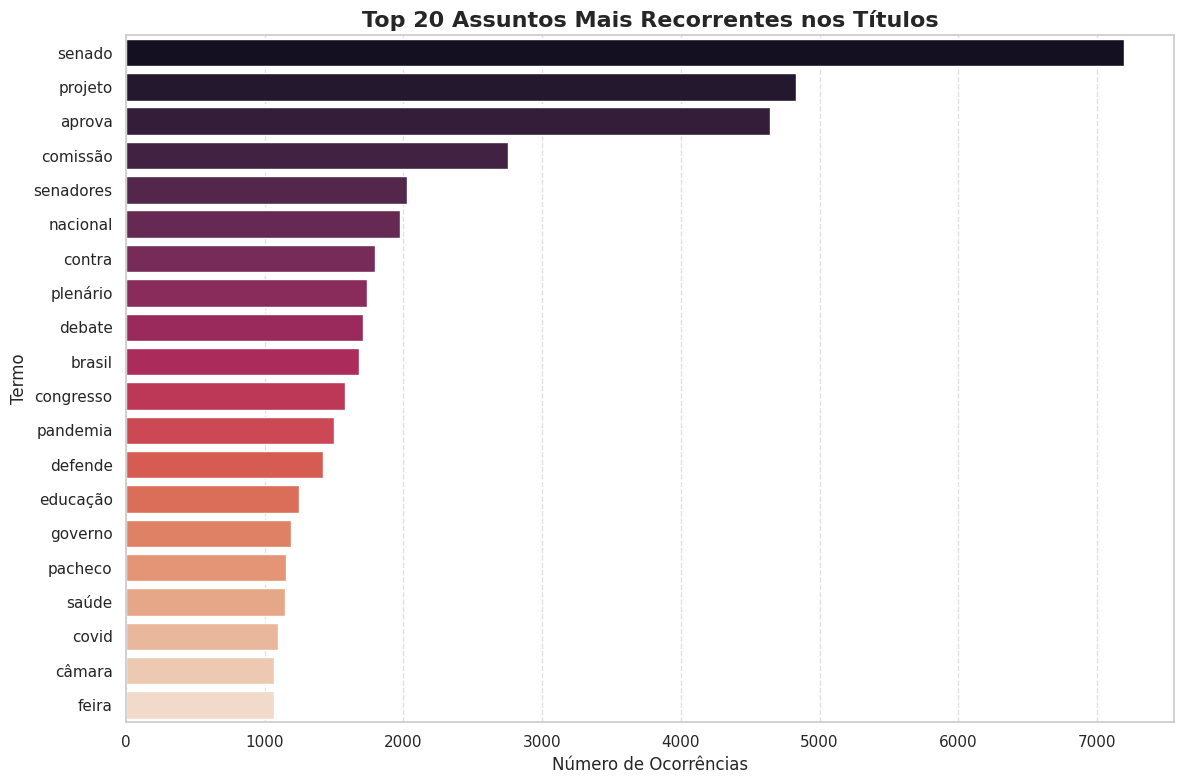

In [31]:
import re
from collections import Counter

# Lista simples de stopwords em português
stopwords = set(['para', 'com', 'uma', 'pelo', 'pela', 'mais', 'sobre', 'entre', 'como', 'esta', 'está', 'pode', 'após', 'nesta', 'neste', 'pelo', 'pelas', 'pelos', 'será', 'serão', 'pode', 'podem', 'pela', 'pelas', 'isso', 'esse', 'essa', 'este', 'esta', 'seus', 'suas'])

def get_top_subjects(df, n=20):
    # Junta todos os títulos
    text = ' '.join(df['title'].astype(str)).lower()
    # Extrai palavras com 5 ou mais letras (ajuda a focar em termos com significado)
    words = re.findall(r'\b\w{5,}\b', text)
    # Filtra stopwords
    filtered_words = [w for w in words if w not in stopwords]

    return Counter(filtered_words).most_common(n)

top_subjects = get_top_subjects(df_db)
subjects_df = pd.DataFrame(top_subjects, columns=['Assunto', 'Frequência'])

# Visualização
plt.figure(figsize=(12, 8))
sns.barplot(data=subjects_df, x='Frequência', y='Assunto', palette='rocket', hue='Assunto', legend=False)

plt.title('Top 20 Assuntos Mais Recorrentes nos Títulos', fontsize=16, fontweight='bold')
plt.xlabel('Número de Ocorrências', fontsize=12)
plt.ylabel('Termo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Correlação de Pearson entre Volume Total e Termo 'Projeto': 0.7084


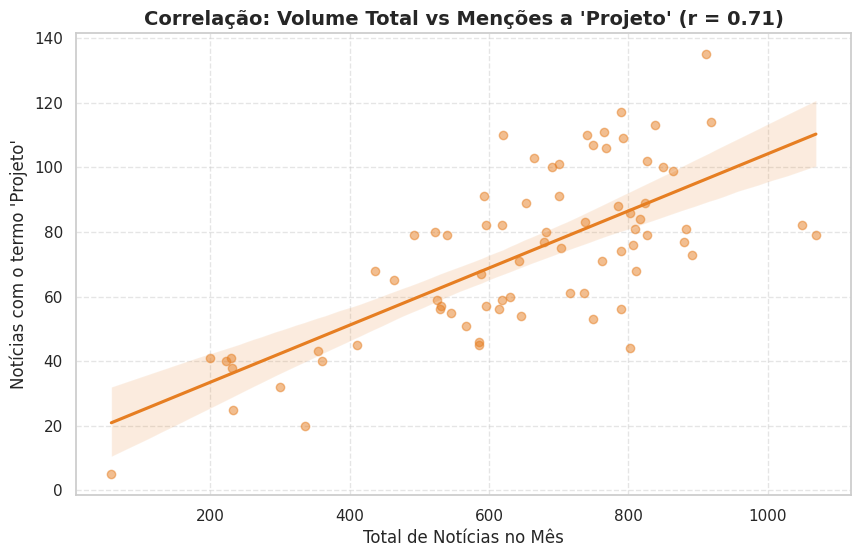

,month_year,total_news,projeto_news
65,2025-08,790,56
66,2025-09,891,73
67,2025-10,806,76
68,2025-11,646,54
69,2025-12,531,57
70,2026-01,231,38
71,2026-02,463,65
72,2026-03,826,79
73,2026-04,596,57
74,2026-05,58,5


In [32]:
# 1. Identificar notícias que contém a palavra 'projeto' (case insensitive)
df_temporal['has_projeto'] = df_temporal['title'].str.contains('projeto', case=False, na=False)

# 2. Agrupar volume total e volume de 'projeto' por mês
monthly_stats = df_temporal.groupby('month_year').agg(
    total_news=('id', 'count'),
    projeto_news=('has_projeto', 'sum')
).reset_index()

# 3. Calcular a correlação
correlation = monthly_stats['total_news'].corr(monthly_stats['projeto_news'])

print(f"Correlação de Pearson entre Volume Total e Termo 'Projeto': {correlation:.4f}")

# 4. Visualização com gráfico de dispersão e linha de tendência
plt.figure(figsize=(10, 6))
sns.regplot(data=monthly_stats, x='total_news', y='projeto_news', color='#e67e22', scatter_kws={'alpha':0.5})

plt.title(f'Correlação: Volume Total vs Menções a \'Projeto\' (r = {correlation:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Total de Notícias no Mês')
plt.ylabel('Notícias com o termo \'Projeto\'')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

display(monthly_stats.tail(10))

Correlação entre Volume Total e 'Governança/Internet': 0.3736


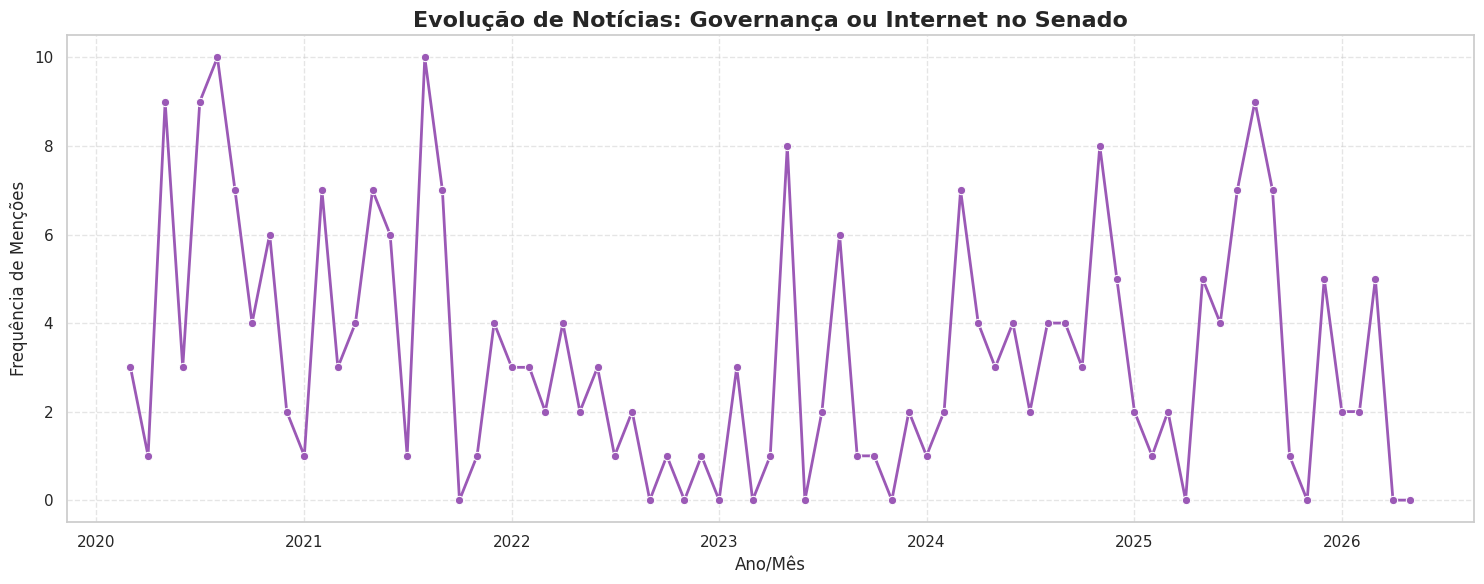

,month_year,total_news,internet_gov_news
5,2020-08,665,10
17,2021-08,911,10
4,2020-07,653,9
65,2025-08,790,9
2,2020-05,740,9
38,2023-05,1049,8
56,2024-11,701,8
6,2020-09,679,7
18,2021-09,849,7
64,2025-07,681,7


In [33]:
# 1. Identificar notícias sobre Governança da Internet
# Usando regex para capturar variações e os dois termos próximos
df_temporal['is_internet_gov'] = df_temporal['title'].str.contains('governança|internet', case=False, na=False)

# 2. Agrupar volume
internet_gov_stats = df_temporal.groupby('month_year').agg(
    total_news=('id', 'count'),
    internet_gov_news=('is_internet_gov', 'sum')
).reset_index()

# 3. Calcular a correlação específica
corr_ig = internet_gov_stats['total_news'].corr(internet_gov_stats['internet_gov_news'])

print(f"Correlação entre Volume Total e 'Governança/Internet': {corr_ig:.4f}")

# 4. Visualização Temporal Específica
plt.figure(figsize=(15, 6))
sns.lineplot(data=internet_gov_stats, x=internet_gov_stats['month_year'].dt.to_timestamp(), y='internet_gov_news', color='#9b59b6', marker='o', linewidth=2)

plt.title('Evolução de Notícias: Governança ou Internet no Senado', fontsize=16, fontweight='bold')
plt.xlabel('Ano/Mês')
plt.ylabel('Frequência de Menções')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Exibir meses com maior incidência do tema
display(internet_gov_stats.sort_values(by='internet_gov_news', ascending=False).head(10))

In [37]:
# Filtrando os títulos de 2025 que tratam de Governança/Internet (Todos os meses)
noticias_ig_2025 = df_temporal[
    (df_temporal['date_dt'].dt.year == 2025) &
    (df_temporal['is_internet_gov'] == True)
].sort_values(by='date_dt')[['date', 'title', 'url']]

print(f"Encontradas {len(noticias_ig_2025)} notícias sobre Governança/Internet em 2025:")
display(noticias_ig_2025)

Encontradas 43 notícias sobre Governança/Internet em 2025:


,date,title,url
17494,20/01/2025 10h04,Projeto garante cancelamento online imediato d...,https://www12.senado.leg.br/noticias/materias/...
14531,22/01/2025 17h54,Projeto garante remunerar obra audiovisual exe...,https://www12.senado.leg.br/noticias/materias/...
33690,10/02/2025 09h13,"Aos 29 anos, TV Senado se consolida também na ...",https://www12.senado.leg.br/noticias/videos/20...
30185,12/03/2025 16h41,CTFC aprova acesso ao Cadastro Positivo de cré...,https://www12.senado.leg.br/noticias/materias/...
9488,25/03/2025 14h11,Novo PNE: monitoramento e sistema de governanç...,https://www12.senado.leg.br/noticias/materias/...
28230,13/05/2025 08h34,"Projeto dificulta a venda, pela internet, de i...",https://www12.senado.leg.br/noticias/materias/...
15477,21/05/2025 16h05,Teresa Leitão defende educação contra riscos d...,https://www12.senado.leg.br/noticias/materias/...
7626,26/05/2025 14h48,CMA debate governança climática no contexto da...,https://www12.senado.leg.br/noticias/materias/...
3149,29/05/2025 16h51,Debate chama atenção para governança climática...,https://www12.senado.leg.br/noticias/materias/...
3142,29/05/2025 18h47,Cleitinho critica julgamento do STF sobre marc...,https://www12.senado.leg.br/noticias/materias/...


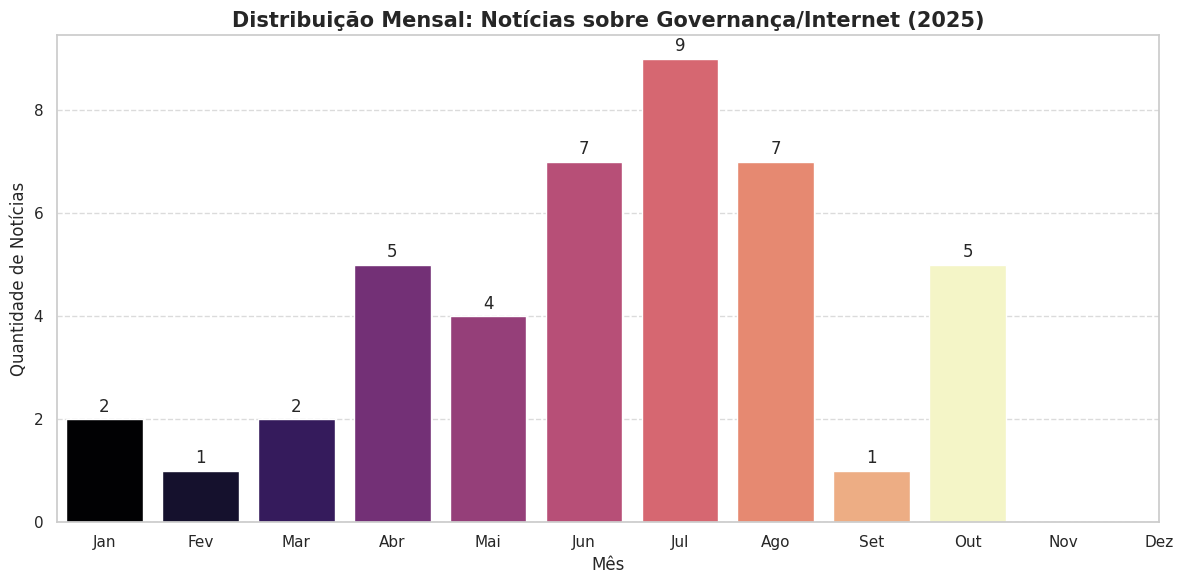

In [38]:
# Agrupando as notícias de Governança da Internet de 2025 por mês
df_ig_2025 = df_temporal[(df_temporal['date_dt'].dt.year == 2025) & (df_temporal['is_internet_gov'] == True)].copy()
df_ig_2025['month'] = df_ig_2025['date_dt'].dt.month

monthly_ig_2025 = df_ig_2025.groupby('month').size().reset_index(name='count')

# Plotagem
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=monthly_ig_2025, x='month', y='count', palette='magma', hue='month', legend=False)

plt.title('Distribuição Mensal: Notícias sobre Governança/Internet (2025)', fontsize=15, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Quantidade de Notícias', fontsize=12)
plt.xticks(range(0, 12), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando rótulos de valor nas barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

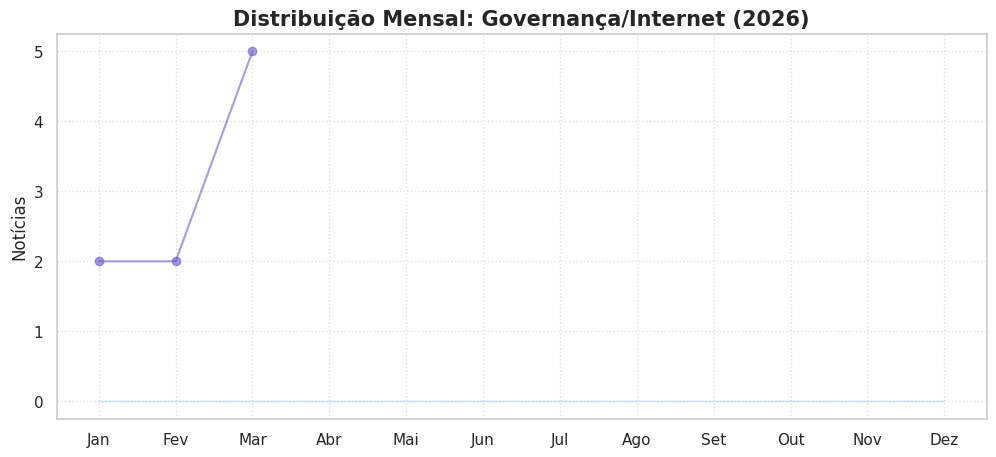

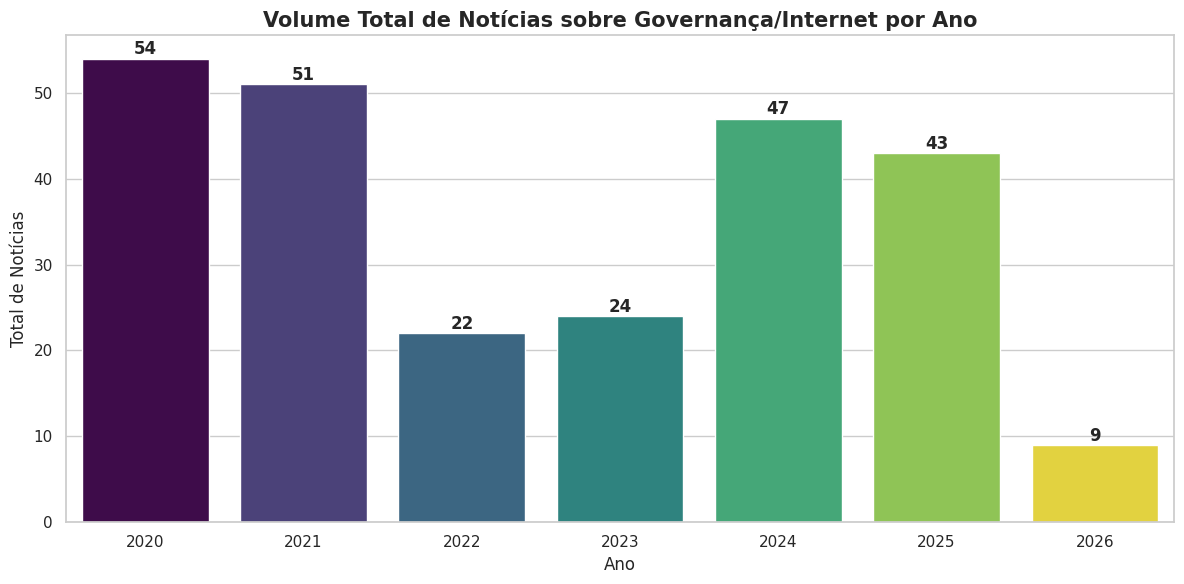

In [39]:
# 1. Preparação dos dados para 2026
df_ig_2026 = df_temporal[(df_temporal['date_dt'].dt.year == 2026) & (df_temporal['is_internet_gov'] == True)].copy()
df_ig_2026['month'] = df_ig_2026['date_dt'].dt.month
monthly_ig_2026 = df_ig_2026.groupby('month').size().reset_index(name='count')

# 2. Preparação dos dados para todos os anos
df_ig_all = df_temporal[df_temporal['is_internet_gov'] == True].copy()
df_ig_all['year'] = df_ig_all['date_dt'].dt.year
yearly_stats = df_ig_all.groupby('year').size().reset_index(name='total_year')

# Plotagem de 2026 (Gráfico de área para diferenciar)
plt.figure(figsize=(12, 5))
plt.fill_between(range(1, 13), 0, color="skyblue", alpha=0.4)
plt.plot(monthly_ig_2026['month'], monthly_ig_2026['count'], color="Slateblue", alpha=0.6, marker='o')
plt.title('Distribuição Mensal: Governança/Internet (2026)', fontsize=15, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.ylabel('Notícias')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Plotagem Comparativa: Todos os Anos (Gráfico de Barras Agrupado/Colorido)
plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_stats, x='year', y='total_year', palette='viridis', hue='year', legend=False)
plt.title('Volume Total de Notícias sobre Governança/Internet por Ano', fontsize=15, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Total de Notícias')
for i, val in enumerate(yearly_stats['total_year']):
    plt.text(i, val + 0.5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# Listando os títulos de 2026 para conferência
print(f"Notícias encontradas em 2026: {len(df_ig_2026)}")
display(df_ig_2026[['date', 'title']].sort_values(by='date'))

Notícias encontradas em 2026: 9


,date,title
43716,04/02/2026 14h54,Projeto obriga órgãos públicos de defesa do co...
43602,04/03/2026 11h13,Política de governança da administração públic...
40207,06/03/2026 13h00,Política de governança para a administração pú...
38894,07/01/2026 10h22,CMA analisa política de governança climática
38888,07/01/2026 15h39,Nova lei pode ampliar acesso à internet banda ...
28710,13/02/2026 15h33,CMA pode votar em breve projeto sobre governan...
20362,18/03/2026 20h01,Senado adia votação de projeto contra discurso...
20359,18/03/2026 20h20,Comissões vão votar projeto de combate ao ódio...
510,31/03/2026 17h18,Veneziano elogia avanços na educação e no aces...
